In [ ]:
import numpy as np
import glob
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
f='../postp/oaat_postp.nc'
ds=xr.open_dataset(f)

In [5]:
def add_lab(ax,c,dx=0.05,dy=0.95):
    x1,x2=ax.get_xlim()
    y1,y2=ax.get_ylim()
    ax.text(x1+dx*(x2-x1),
            y1+dy*(y2-y1),
            '('+c+')',ha='center',va='center')

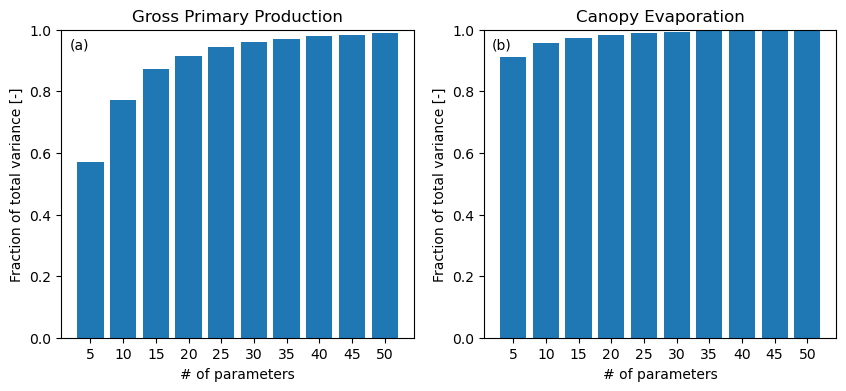

In [6]:
pchunk=5
vsavs=[]
plt.figure(figsize=[10,4])
lns={'FCEV':'Canopy Evaporation','GPP':'Gross Primary Production'}
abcd='abcd'
for i,dv in enumerate(['GPP','FCEV']):

    da=ds[dv+'_global_mean'].sel(exp='CTL2010')
    v=((da-da.sel(param='default',minmax='min'))**2).sum(dim='minmax')
    g=xr.DataArray(pchunk+pchunk*np.floor(np.arange(212)/pchunk),
                   dims='param',name='nparams')
    vcumsum=v.sortby(v,ascending=False).groupby(g).sum().cumsum(dim='nparams')/v.sum()
    vsavs.append(vcumsum)
    ax=plt.subplot(121+i)
    plt.bar(vcumsum.nparams[:10],vcumsum[:10],width=4)
    plt.title(lns[dv]);
    plt.xlabel('# of parameters')
    plt.ylabel('Fraction of total variance [-]');
    plt.ylim([0,1])
    plt.xticks(vcumsum.nparams[:10]);
    add_lab(ax,abcd[i])

plt.savefig('../figs/main/variance.png',dpi=300,bbox_inches='tight')